In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# using 'Science' style plots
plt.style.use(['science', 'high-vis'])

J = sp.Symbol("J", real=True, positive=True)
epsilon  = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)

In [17]:
def L_eff(N, num_dimers=2):
    # building matrices
    H0 = sp.Matrix(N, N, lambda i,j : J if ({i,j} in [{2*k, 2*k+1} for k in range(num_dimers)]) else 0)
    V = sp.Matrix(N, N, lambda i,j : 0 if ({i,j} in [{2*k, 2*k+1} for k in range(num_dimers)] or i==j) else epsilon)
    
    # building lindblad jump operators
    L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]
    
    # building lindbladians
    L0, rho = lindbladian(N, output=False, degenerate=False, H=H0, L_operators=L_operators)
    L1, _ = lindbladian(N, output=False, degenerate=False, H=V, dissipative=False)
    
    # setting all dephasing constants to the same constant gamma
    L0 = L0.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(N)})
    
    # constructing projector (and its complement)
    nullspace = [n/n.norm() for n in L0.nullspace()]
    P = sp.Add(*[  u*u.transpose() for u in nullspace  ])
    Q = sp.eye(sp.shape(P)[0]) - P

    # building Leff and Leff_red
    Leff = ((Q*L1*P).conjugate().transpose()*(Q*L0*Q).pinv()*Q*L1*P).applyfunc(lambda i: i.simplify(deep=True))
    Leff_red = sp.Matrix(len(nullspace), len(nullspace), lambda i,j: (nullspace[i].transpose().conjugate()*Leff*nullspace[j])[0]).applyfunc(lambda expr: expr.simplify().apart(gamma))

    return rho, L0+L1, Leff, Leff_red


In [41]:
def plot_time_series(axs, N, matrix, J_val, epsilon_val, gamma_vals, initial_condition, pop_indices, label=True, reduced_matrix=False, dt=1e1):
    # iterating through different dephasing regimes
    for col, gamma_val in enumerate(gamma_vals):
        
        # for each regime, compute long time-scale value
        lambda1 = 2*N*gamma_val*epsilon_val**2 / ( gamma_val**2 + J_val**2 )
        lambda2 = 4*gamma_val*epsilon_val**2 / ( gamma_val**2 + J_val**2 ) + 2*(N-2)*epsilon_val**2 / gamma_val
        timescale = 1/lambda1
        print(timescale)

        # numerically compute time evolution of density matrix
        times, rhos = solve_lindblad_num(
            matrix.subs({J:J_val, gamma:gamma_val, epsilon:epsilon_val}),
            0.1,
            timescale*1e2,
            timescale*dt,
            initial_condition,
        )

        # plotting populations
        num_dimers = N - len(pop_indices)
        for i, index in enumerate(pop_indices):
            if (i in range(num_dimers)) and reduced_matrix:
                axs[col].plot(times, 
                              rhos[index],
                              label=rf"$\frac{{|{{{2*i+1}}}⟩⟨{{{2*i+1}}}|+|{{{2*i+2}}}⟩⟨{{{2*i+2}}}|}}{{\sqrt2}}$",
                              #label=rf"$D_{{{2*i+1}}}$",
                              linewidth=2*0.95**i,
                              alpha=1*0.95**i
                             )
                axs[col].plot([], []) # null plot to increment color cycle
                
            else:
                axs[col].plot(times, 
                              rhos[index],
                              label=f"{num_dimers+i+1 if reduced_matrix else i+1}",
                              linewidth=2*0.95**i,
                              alpha=1*0.95**i
                             )

        # labelling
        if label: axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[col]))}}}$')
        #axs[col].set_ylim(bottom=0.2, top=1.4)
        axs[col].set_xlabel("Time (s)")
        axs[col].set_xscale('log')
        axs[col].legend(title="Site Pop.:", fontsize="x-small", title_fontsize="small", ncol = N // 2 if (N>3 and not reduced_matrix) or (N>4 and reduced_matrix) else 1)
        axs[col].axvline(1/lambda1,linestyle="--", color="gray", zorder=-1)
        #axs[col].axvline(1/lambda2,linestyle="--", color="black", zorder=-1)

    # labelling
    #axs[0].set_ylabel("Site Populations")


In [43]:
def figure(N, num_dimers, seed=-1, J_val=0.1, epsilon_val=1e-4, gamma_vals=[1e-1, 1e-3, 1e-5], save=True, dt=1e1):
    # setting theme for plot
    plt.style.use(['science',f'discrete-rainbow-{N}'])
    
    # building the Lindbladians
    _, L, Leff, Leff_red = L_eff(N, num_dimers)
    
    # setting up the figure
    fig, axs = plt.subplots(len(gamma_vals),3, figsize=(9, 9), layout='constrained')
    
    # generating seed for random number generator
    # (if you want to reproduce initial conditions, manually input your seed)
    seed = np.random.randint(1000) if seed==-1 else seed
    np.random.seed(seed)
    
    # randomly generating initial populations based on seed
    initial_pops = np.random.rand(N)
    initial_pops = initial_pops/np.sum(initial_pops)
    
    # plotting time series for L, Leff, and Leff_red
    print(np.shape(L))
    plot_time_series(axs[:,0], N, L, J_val, epsilon_val, gamma_vals, np.diag(initial_pops).reshape(N**2), (N+1)*np.arange(N), False, dt=dt)
    plot_time_series(axs[:,1], N, Leff, J_val, epsilon_val, gamma_vals, np.diag(initial_pops).reshape(N**2), (N+1)*np.arange(N), False, dt=dt)
    plot_time_series(axs[:,2], N, Leff_red, J_val, epsilon_val, gamma_vals, 
                     np.array([(initial_pops[2*i]+initial_pops[2*i+1])/np.sqrt(2) if i in range(num_dimers) else initial_pops[num_dimers+i] for i in range(N-num_dimers)]), 
                     np.arange(N-num_dimers), False, reduced_matrix=True, dt=dt)
    
    # adding gamma vals to left side of figure
    for i, val in enumerate(gamma_vals):
        axs[i,0].set_ylabel(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[i]))}}}$')
    
    # find y limits for each plot in figure
    ylim = np.array([axs[i,j].get_ylim() for i in range(len(gamma_vals)) for j in range(3)])
    # setting consistent y limits for each plot (consistent axes make comparisons easier)
    for j in range(3):
        #axs[0,j].legend(title="Site Pop.:", fontsize="x-small", title_fontsize="small", loc="lower left",
        #ncol = min(4, N), fancybox=True, shadow=True, bbox_to_anchor=(0.5, 1.1))
        for i in range(len(gamma_vals)):
            axs[i,j].set_ylim(bottom=np.min(ylim[:,0])-0.1, top=np.max(ylim[:,1]))
            axs[i,j].legend(title="Population:", fontsize="x-small", title_fontsize="small", loc="lower center",
        ncol = min(4, N) if j!=2 else min(3, N), fancybox=True, shadow=False, frameon=True)
    
    # labelling columns
    axs[0,0].set_title(r"$\mathcal{L}$")
    axs[0,1].set_title(r"$\mathcal{L}_\textrm{eff}$")
    axs[0,2].set_title(r"$\mathcal{L}_\textrm{eff}^\textrm{red}$")
    
    # labelling top and left sides
    fig.suptitle(r"Time Evolution of Site Populations under $\mathcal{L}$, $\mathcal{L}_\textrm{eff}$, and $\mathcal{L}_\textrm{eff}^\textrm{red}$" + "\n" + rf"$n$={{{N}}}; $J=10^{{{int(np.log10(J_val))}}}$; $\epsilon=10^{{{int(np.log10(epsilon_val))}}}$")
    fig.supylabel(r"Site Populations with Varying Dephasing $\Gamma$")

    # printing seed
    print(f"seed: {seed}")
    
    if save: fig.savefig(f"N={N}; Ndimers={num_dimers}; seed={seed}; J=10^{int(np.log10(J_val))}; epsilon=10^{int(np.log10(epsilon_val))}.pdf")

(36, 36)
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
seed: 168
(36, 36)
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
seed: 84
(36, 36)
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
seed: 762
(36, 36)
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
seed: 488
(36, 36)
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
1666666.6666666667
83341666.66666667
8333333416.666667
seed: 31


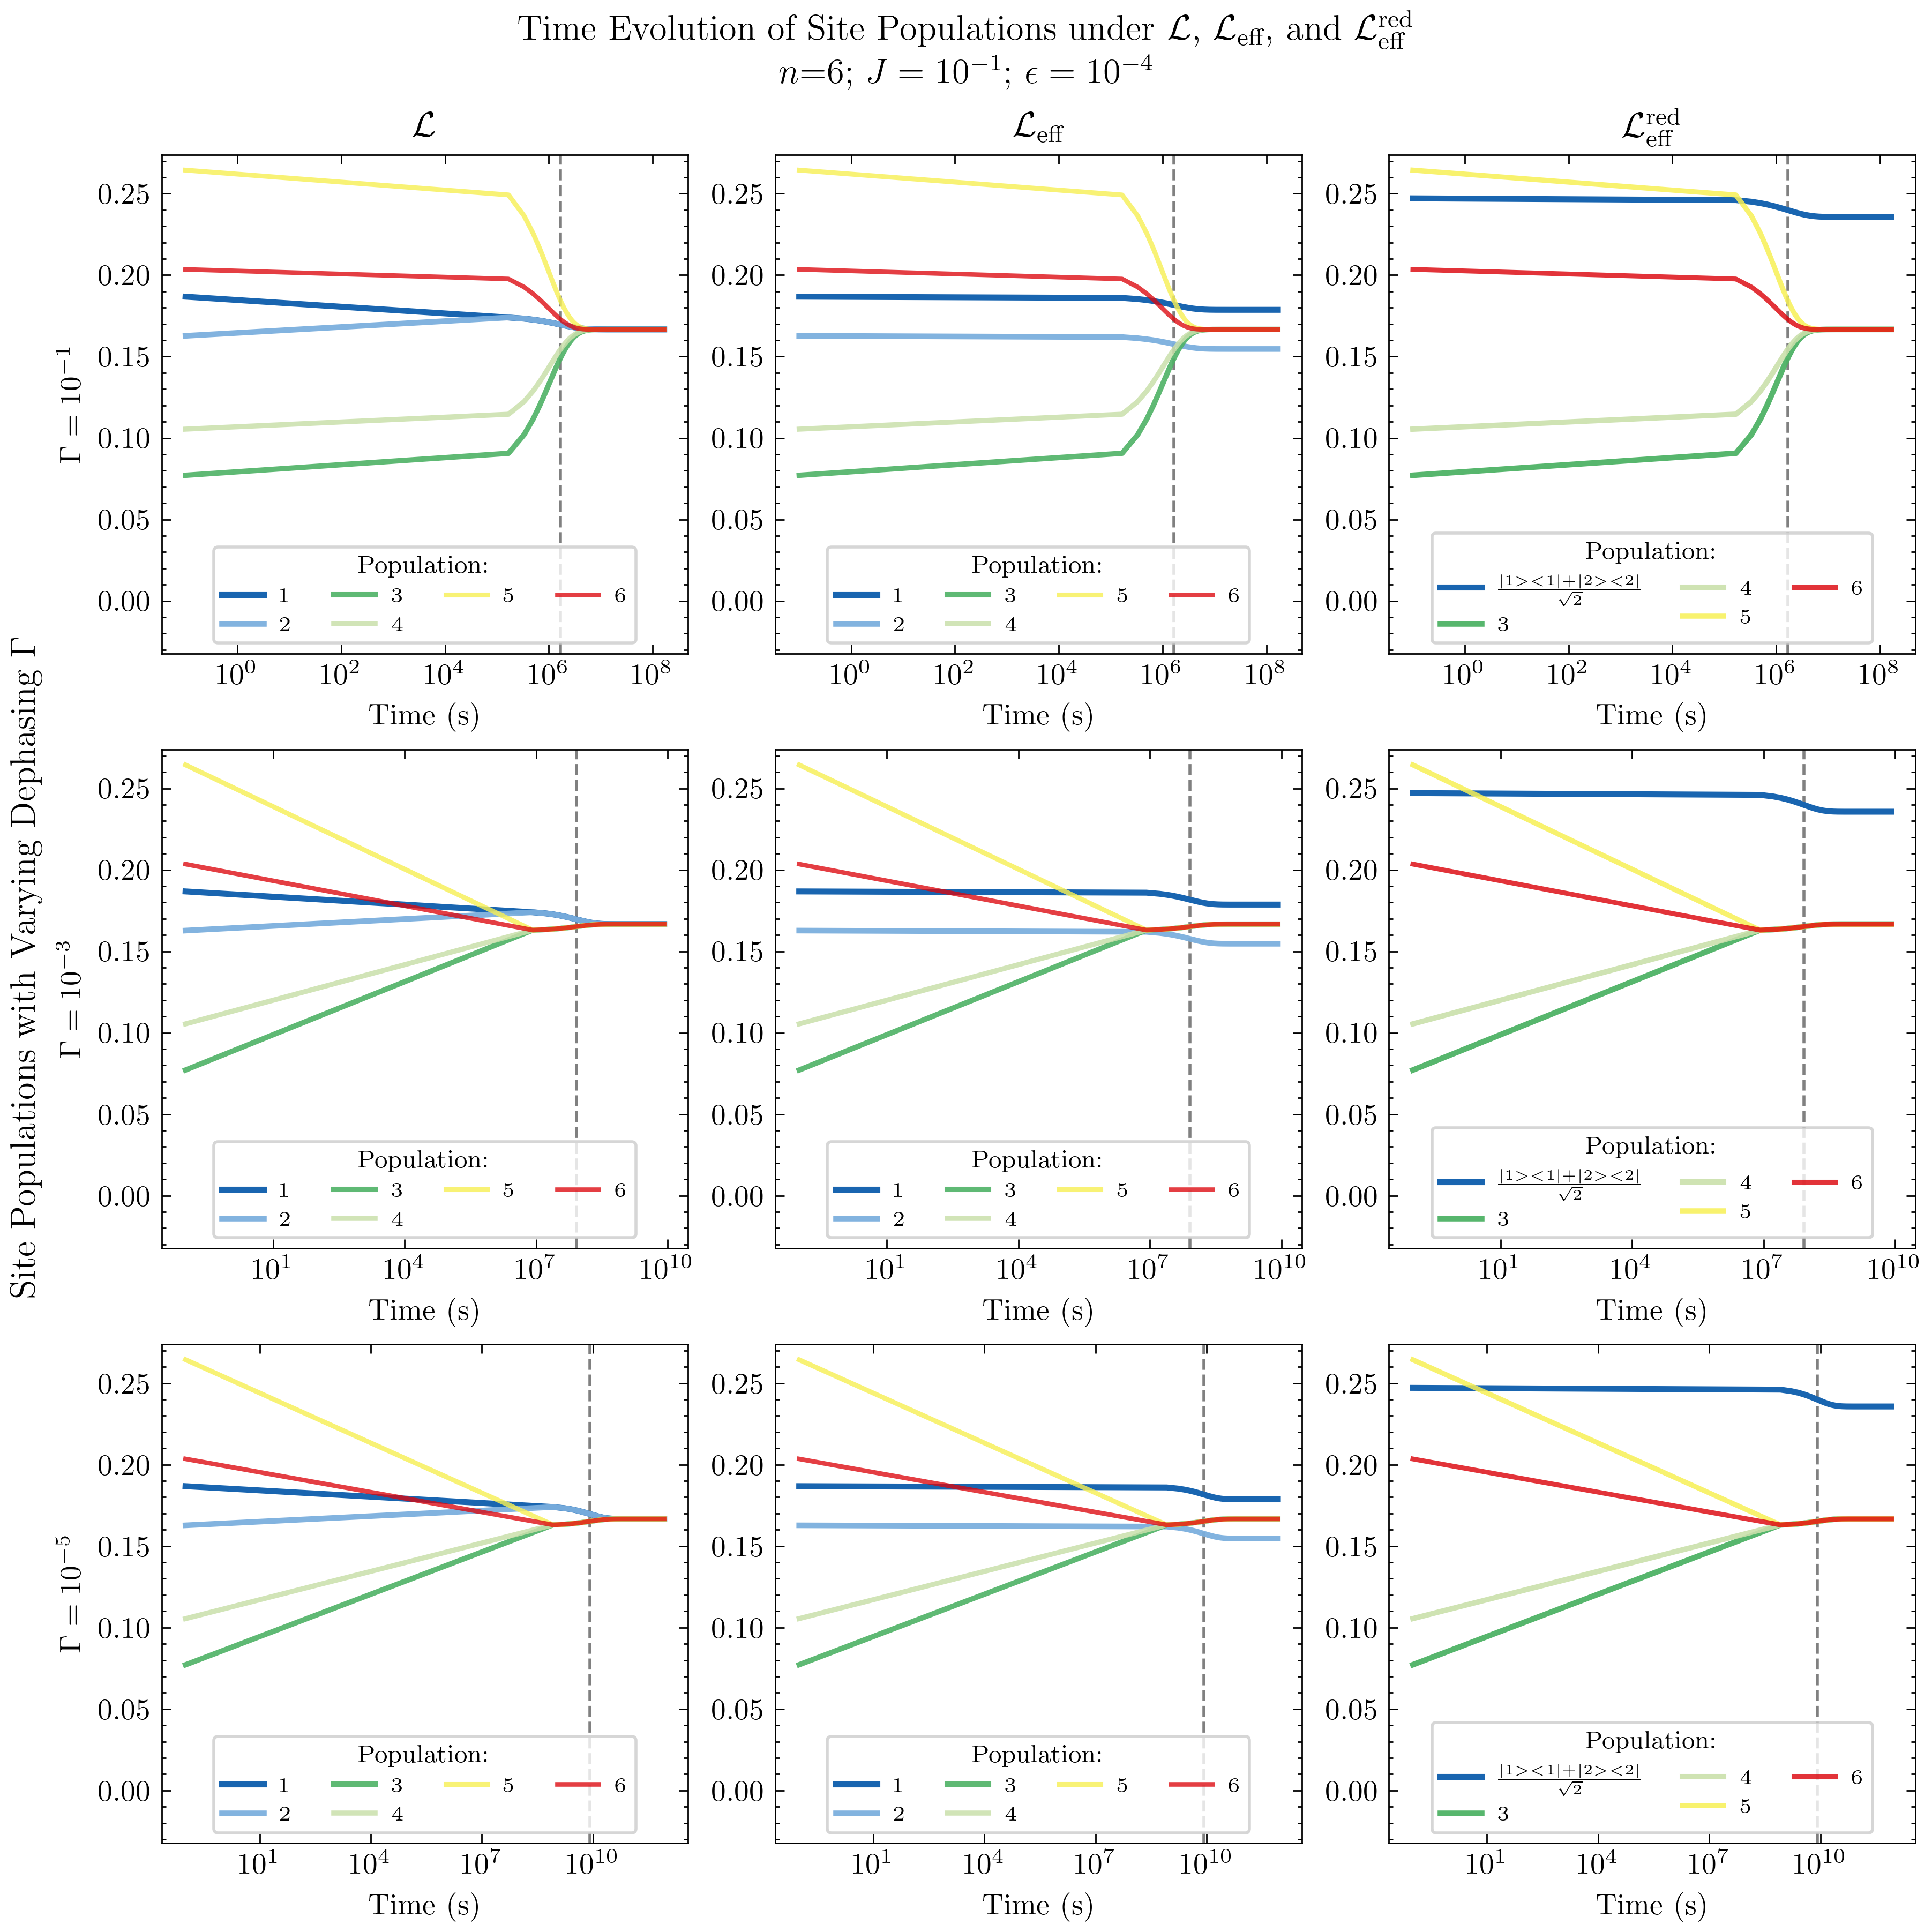

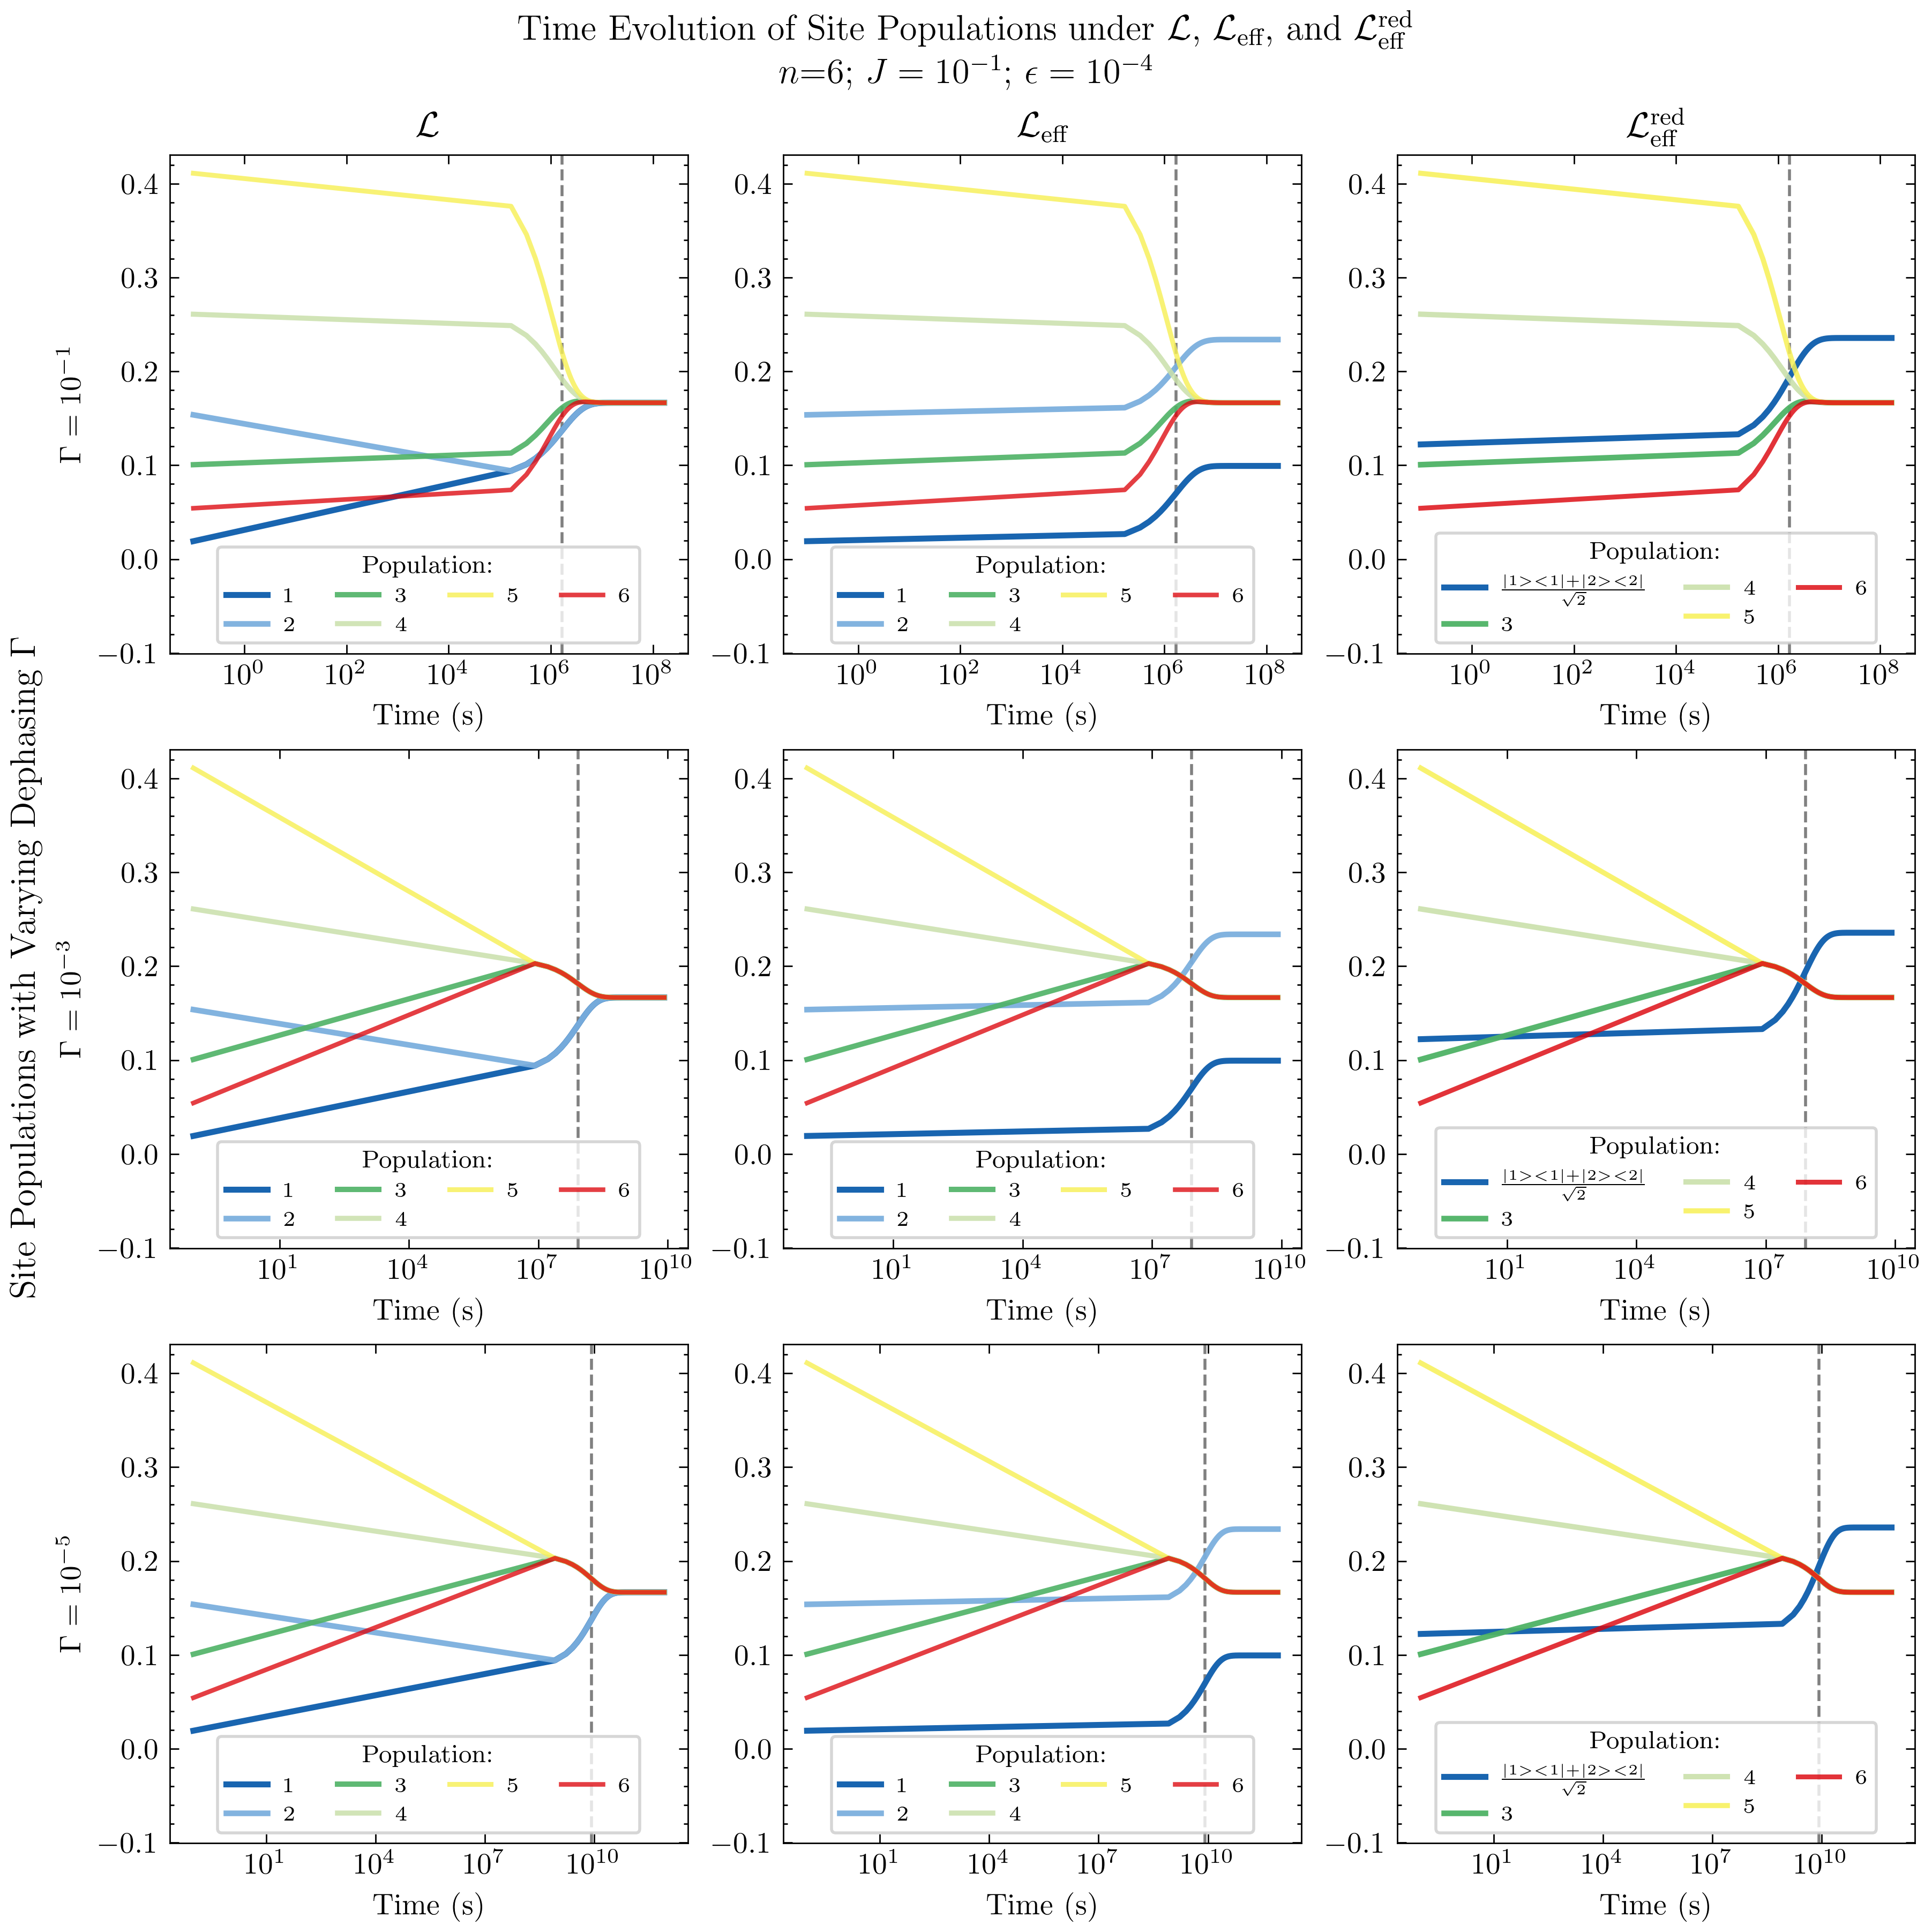

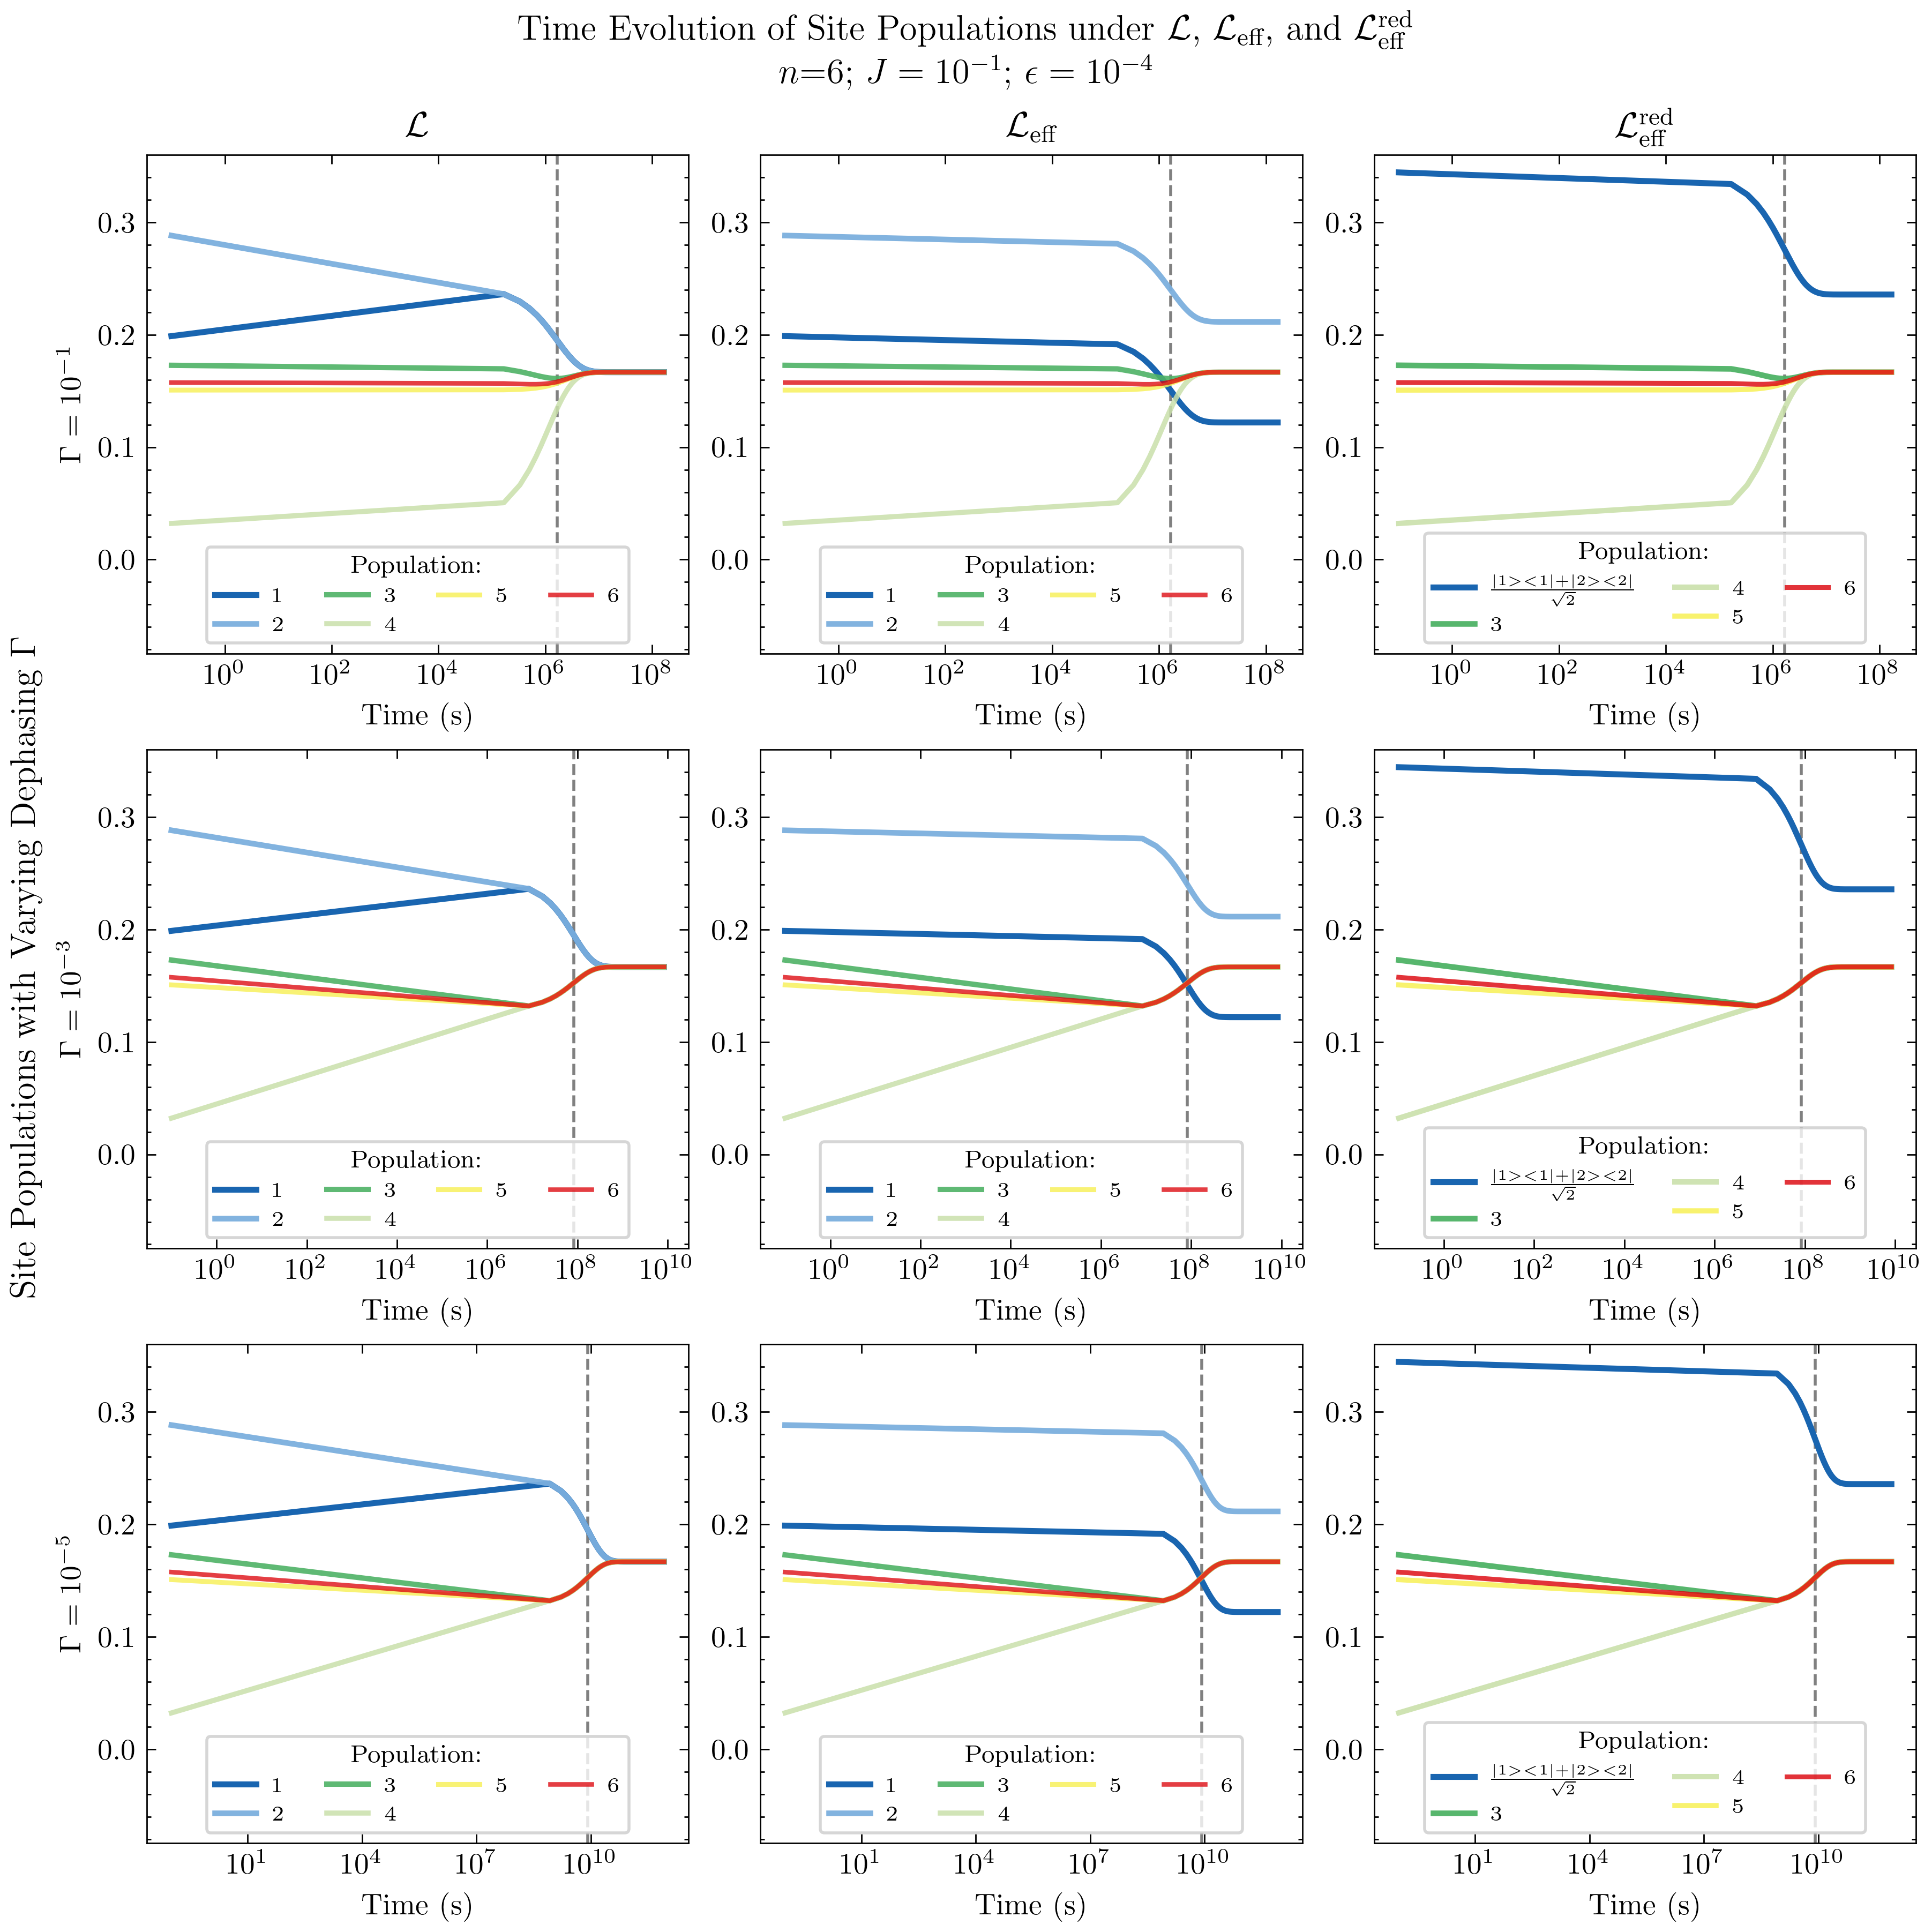

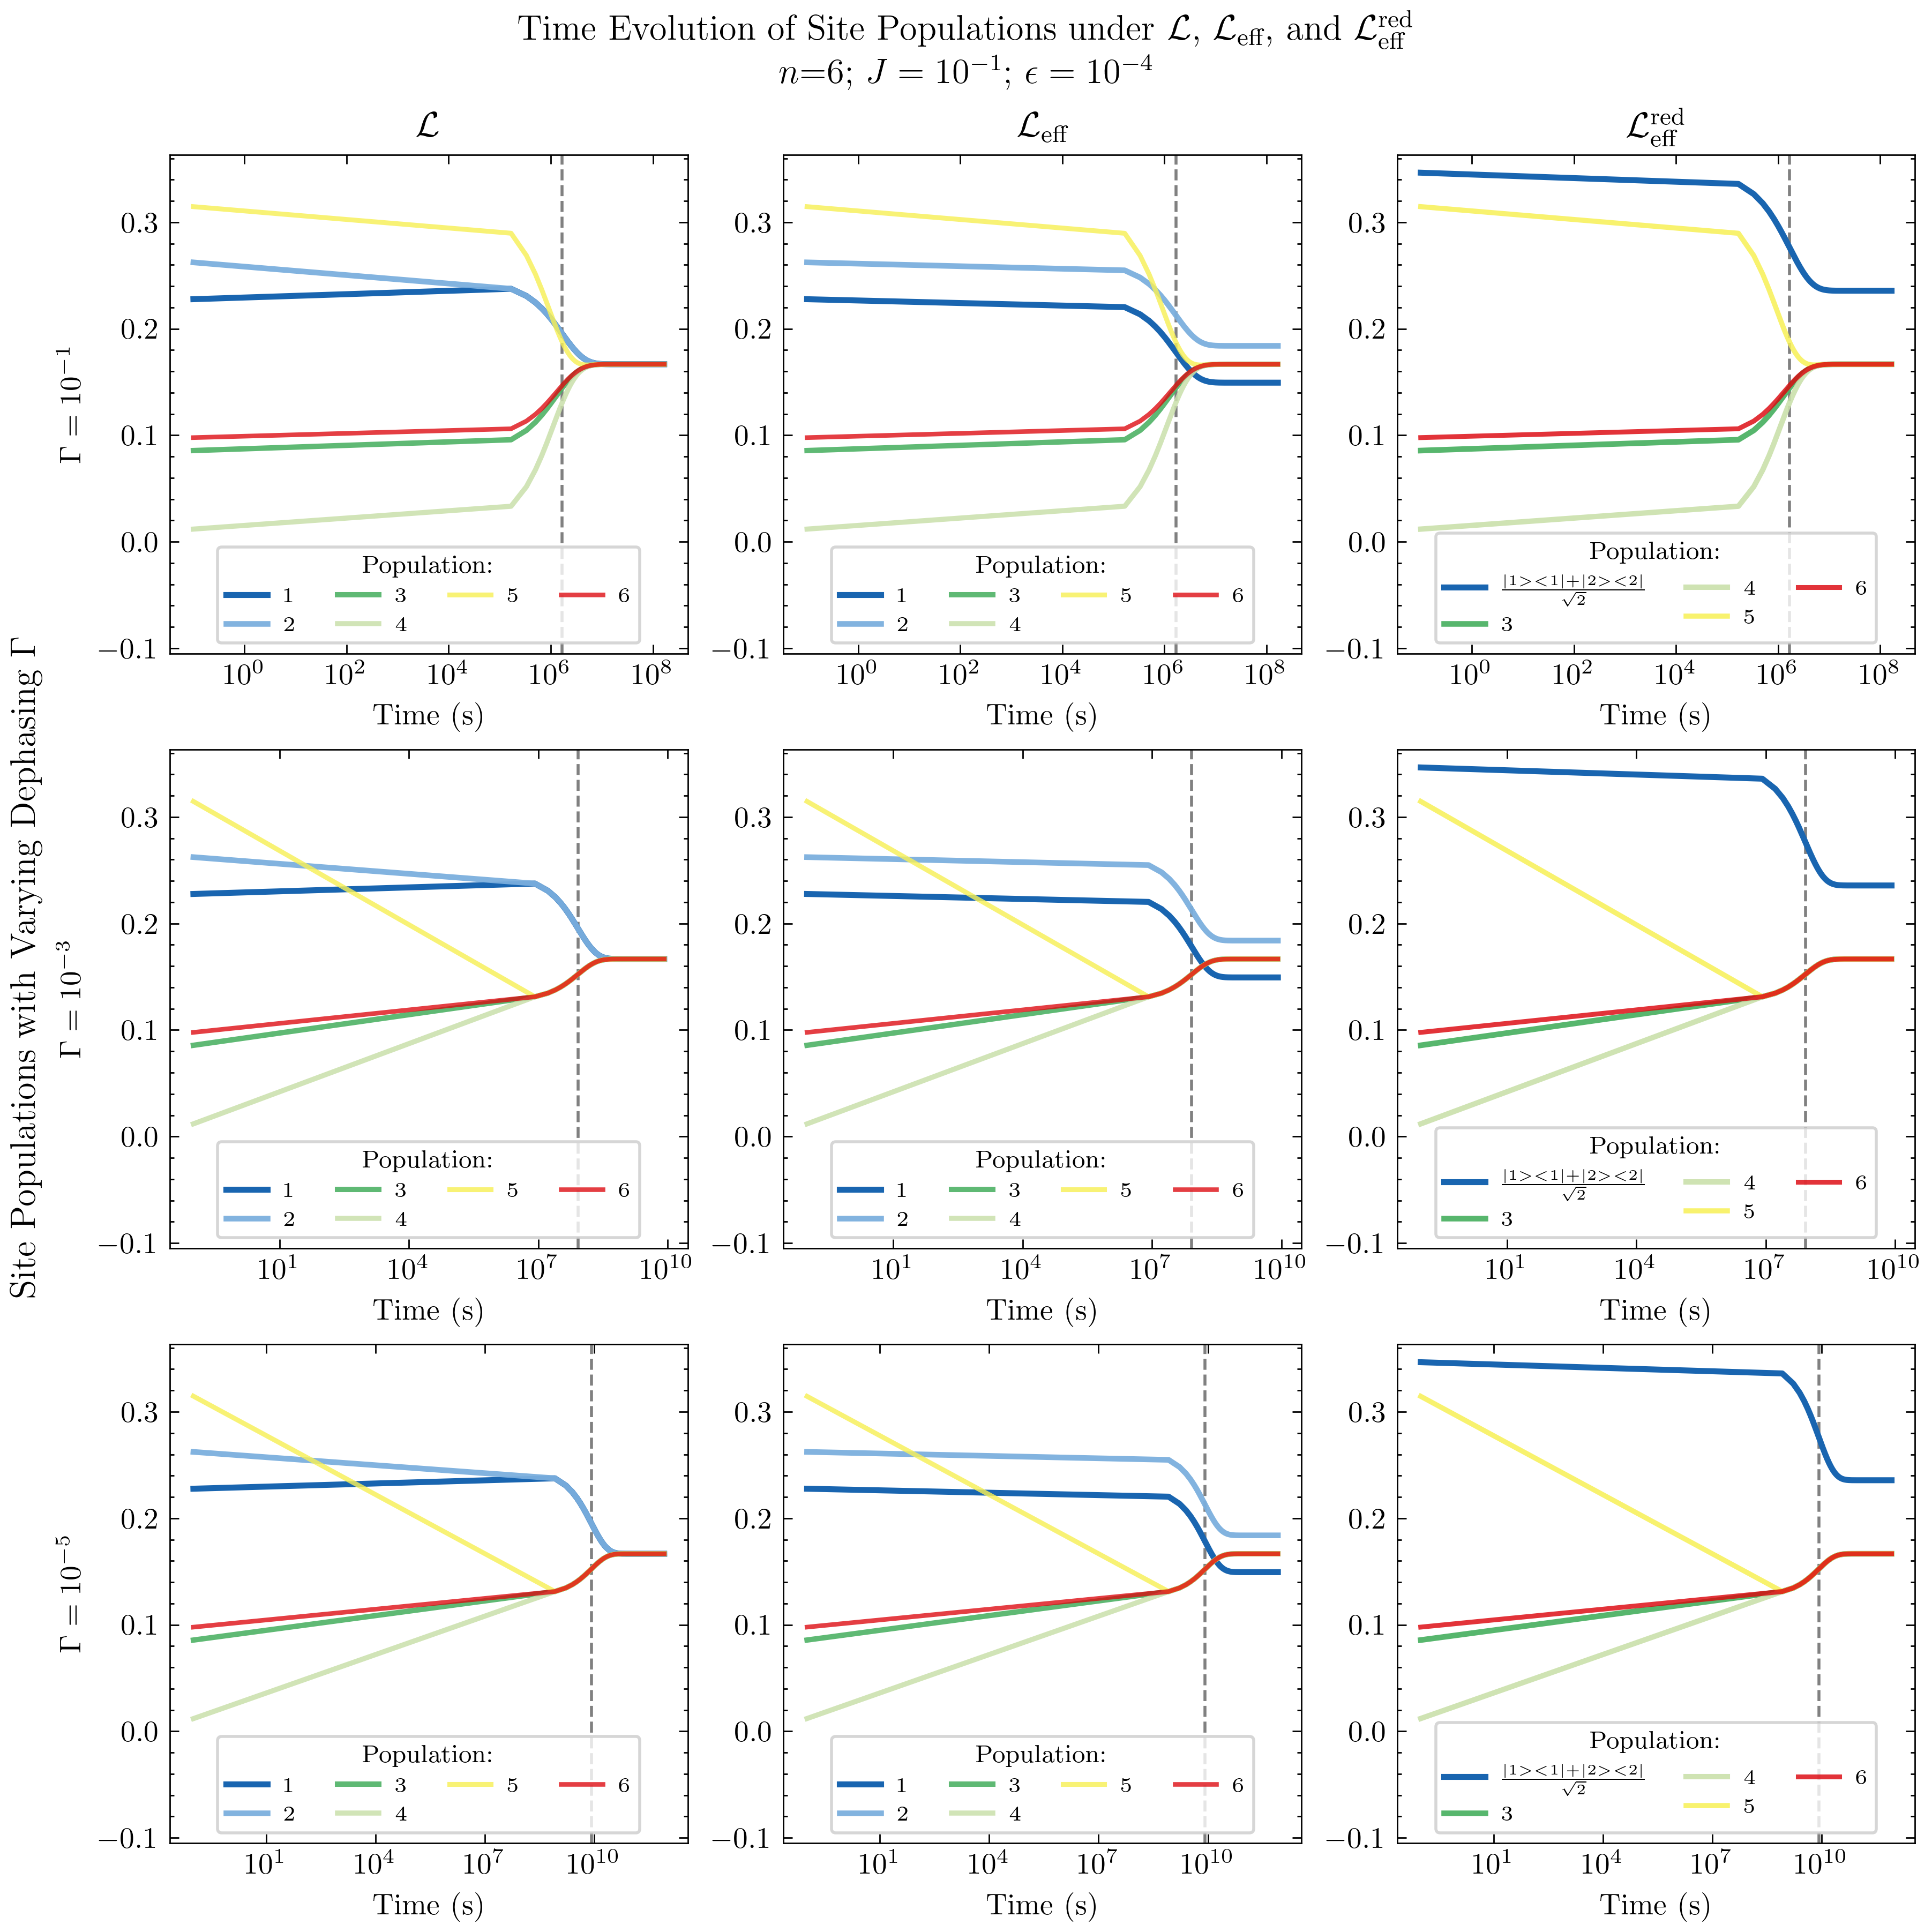

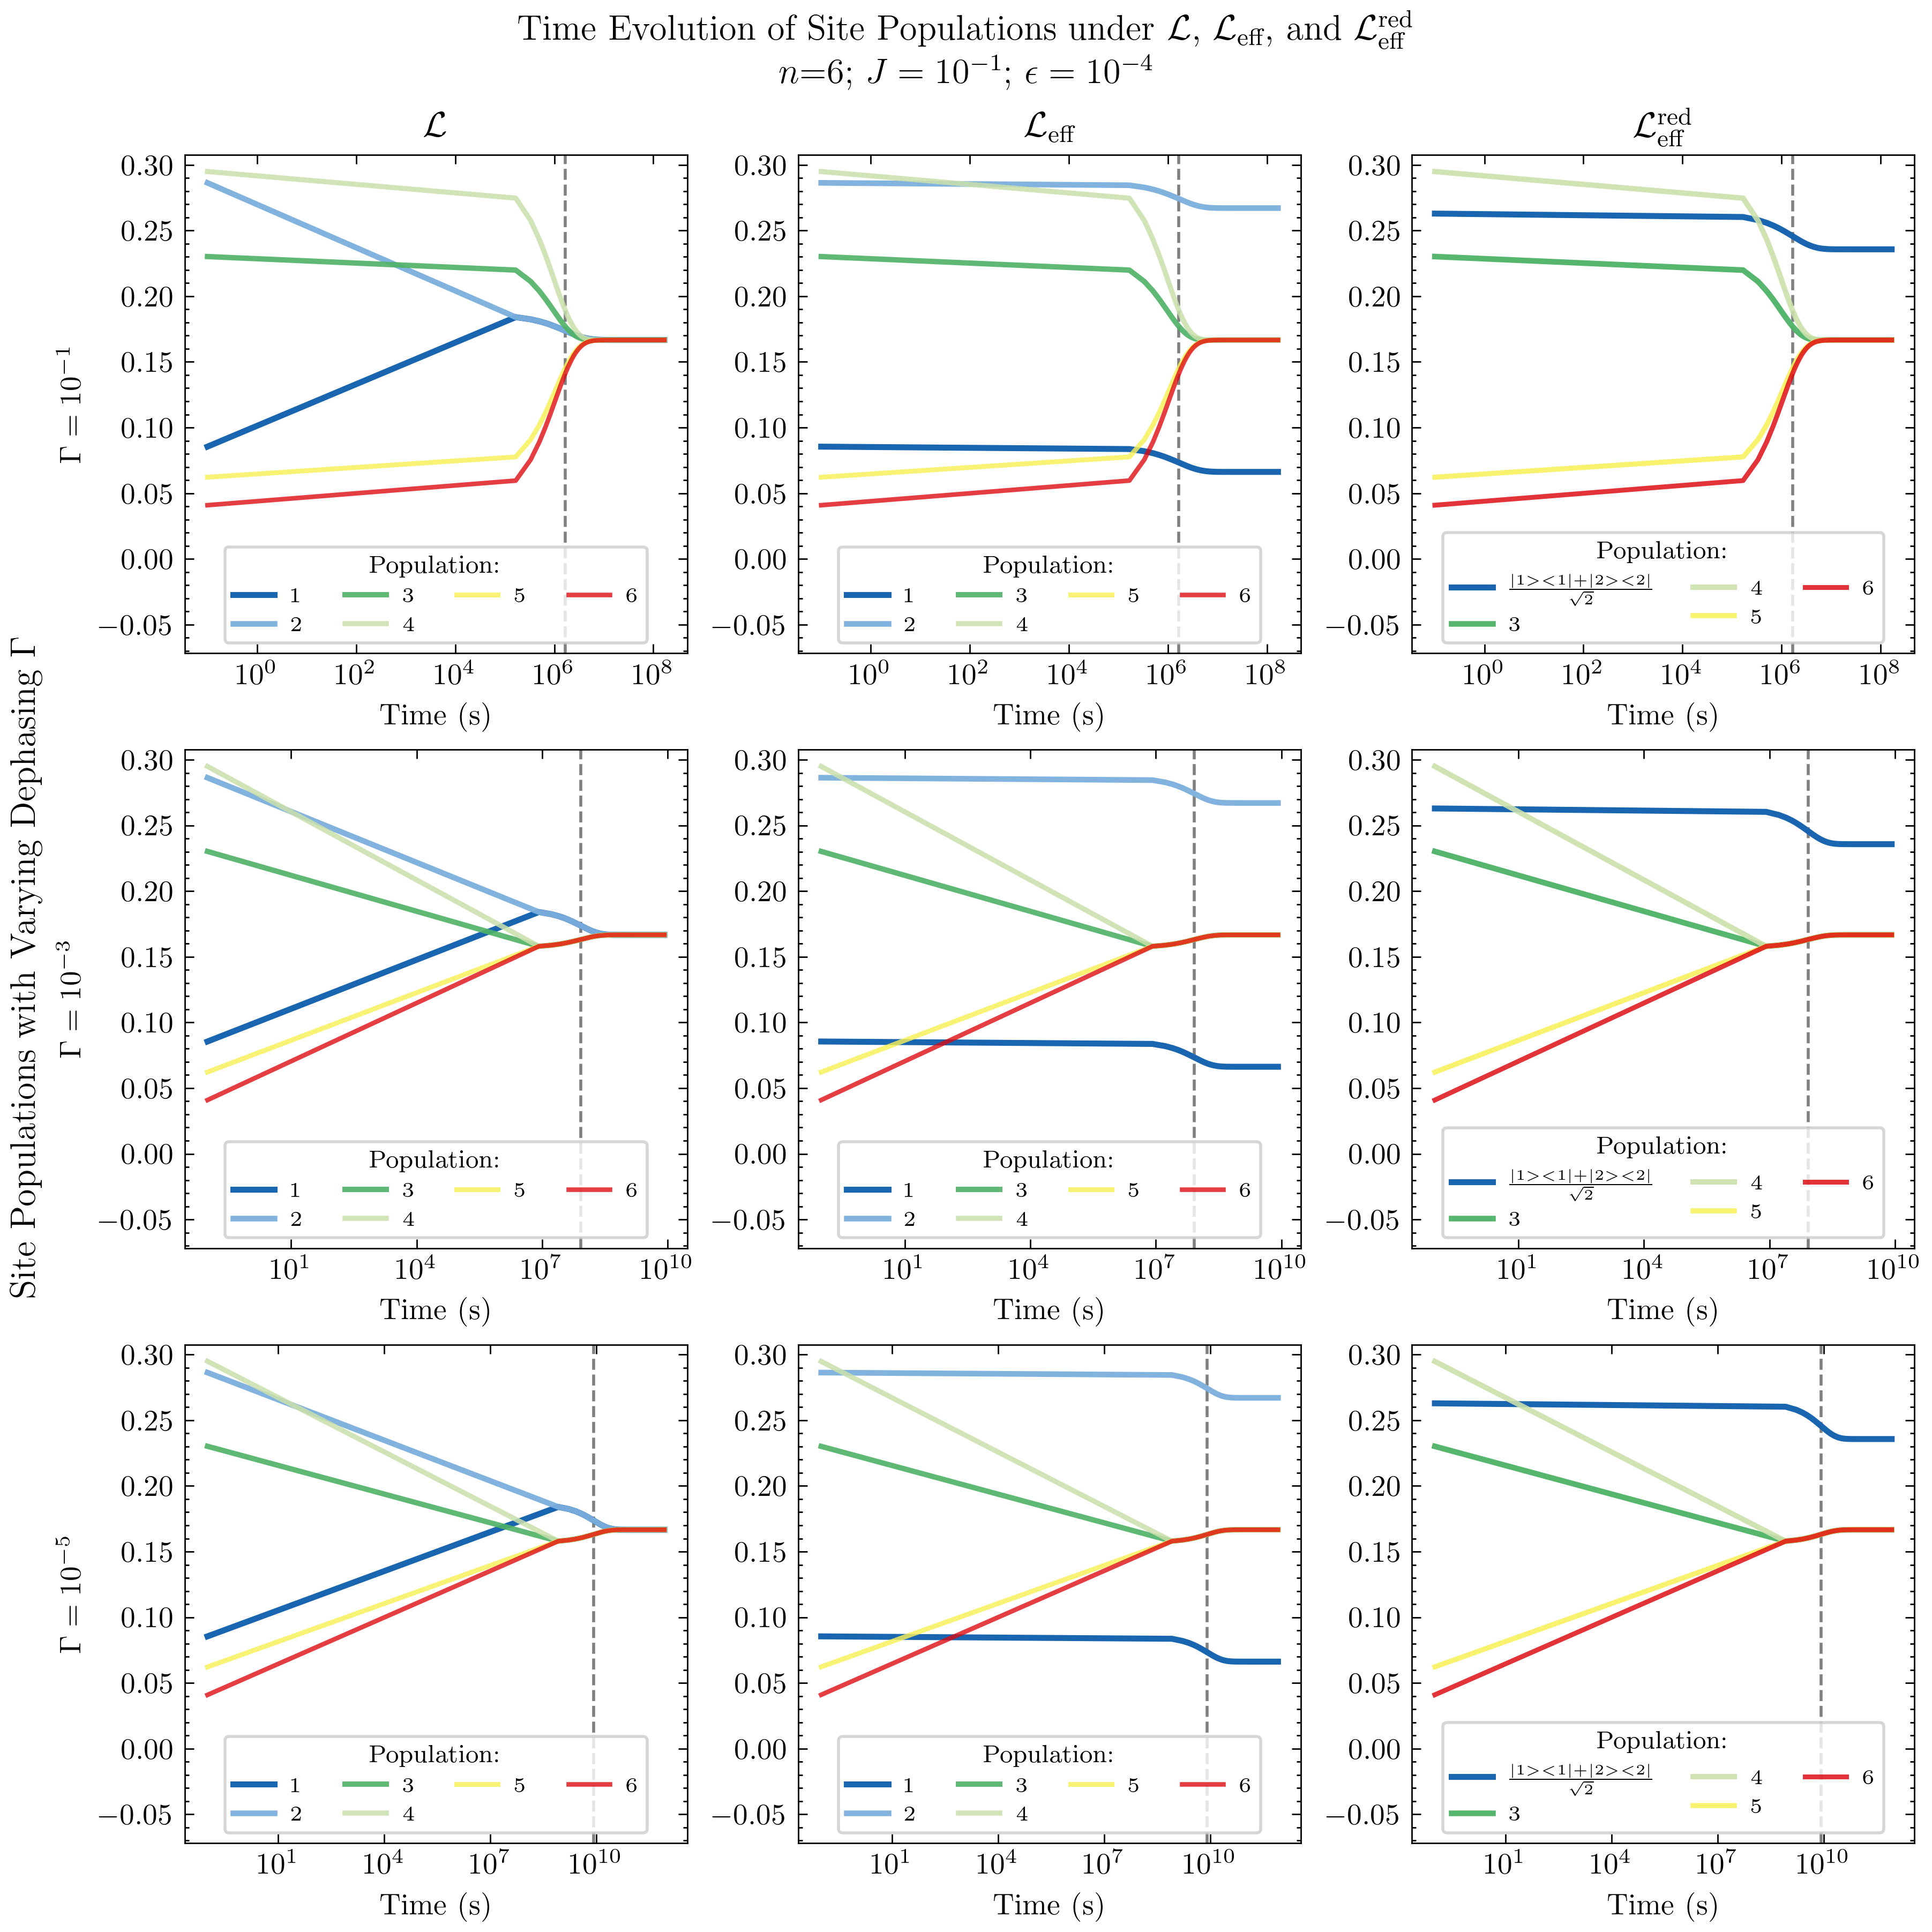

In [46]:
for i in range(5):
    figure(N=6, num_dimers=1, seed=-1, J_val=0.1, epsilon_val=1e-4, gamma_vals=[1e-1, 1e-3, 1e-5], save=True, dt=10**(-1))